In [4]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import math
import numpy as np
import matplotlib.pyplot as plt
import os
#loading the data
df = pd.read_csv('/Users/yashsaraswat/Documents/GitHub/Complex_systems_group1/Module10/PRSA_data_2010.1.1-2014.12.31.csv')

# EDM specific preprocessing - normalisation and datetime indexing
cols = ['pm2.5', 'TEMP', 'PRES', 'DEWP', 'Iws', 'Is', 'Ir']

df[cols] = sklearn.preprocessing.StandardScaler().fit_transform(df[cols])

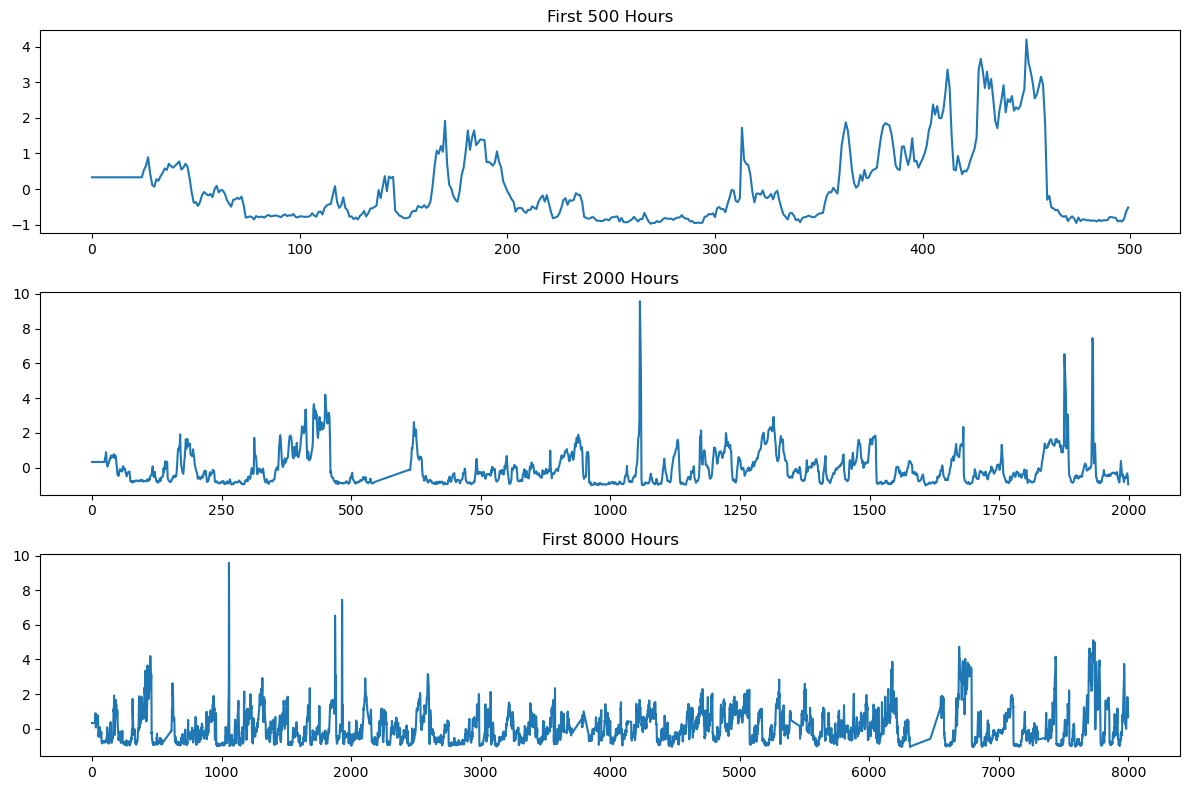

In [5]:
# @title Fixing pm2.5 with linear values with the days before after kind of thing

# The values will be replaced with the linear method as it compares with the days before and after, f and bfill for gaps and edges
df = df.sort_values(['year','month','day','hour']) #just to be sure
df['pm2.5'] = df['pm2.5'].interpolate().bfill().ffill()

df.isna().sum()
x = df['pm2.5'].values

# inspect different zoom levels
fig, axes = plt.subplots(3, 1, figsize=(12,8))
axes[0].plot(x[:500])
axes[0].set_title("First 500 Hours")
axes[1].plot(x[:2000])
axes[1].set_title("First 2000 Hours")
axes[2].plot(x[:8000])
axes[2].set_title("First 8000 Hours")

plt.tight_layout()

plt.show()

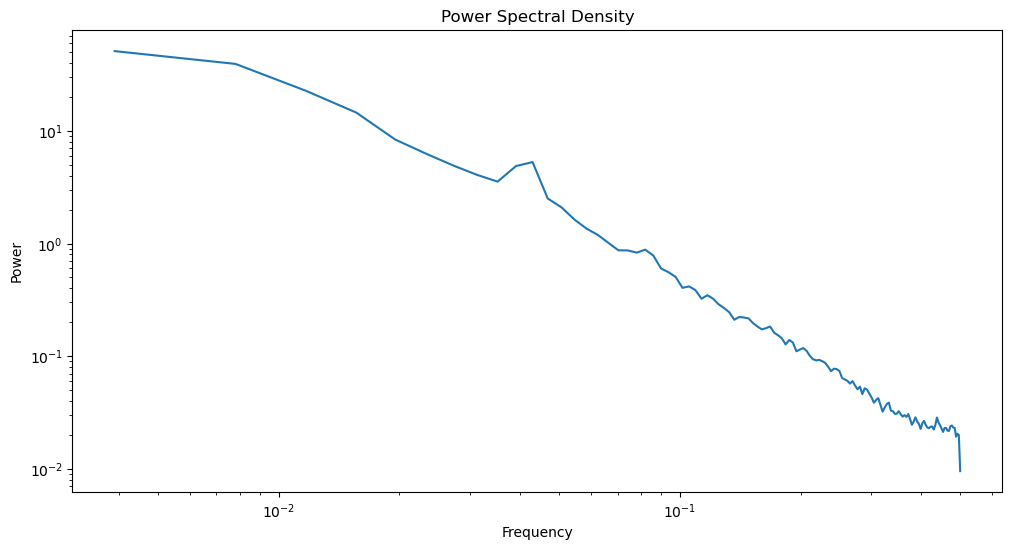

In [6]:
# -----------------------------------
# POWER SPECTRAL DENSITY SCALING
# -----------------------------------

from scipy.signal import welch

x = df['pm2.5'].values

freqs, power = welch(x, fs=1)

plt.figure(figsize=(12,6))
plt.loglog(freqs[1:], power[1:])
plt.xlabel("Frequency")
plt.ylabel("Power")
plt.title("Power Spectral Density")

plt.show()

RAW SCALES (hours):
[4.000e+00 5.000e+00 6.000e+00 8.000e+00 9.000e+00 1.100e+01 1.400e+01
 1.700e+01 2.000e+01 2.400e+01 2.900e+01 3.500e+01 4.200e+01 5.100e+01
 6.100e+01 7.300e+01 8.800e+01 1.060e+02 1.270e+02 1.530e+02 1.840e+02
 2.200e+02 2.640e+02 3.170e+02 3.810e+02 4.570e+02 5.490e+02 6.590e+02
 7.910e+02 9.490e+02 1.139e+03 1.367e+03 1.640e+03 1.968e+03 2.362e+03
 2.835e+03 3.402e+03 4.082e+03]

RAW FLUCTUATIONS:
[-2.24927706 -1.86961714 -1.56453614 -1.12723707 -0.95755604 -0.66463102
 -0.32171965 -0.05825359  0.16804981  0.38000367  0.64138349  0.87261221
  1.08517323  1.32865348  1.54254644  1.75624557  1.96556184  2.17085542
  2.33752438  2.54197321  2.69793509  2.87310786  3.01370576  3.15486814
  3.29535262  3.41592042  3.55326051  3.65276967  3.74496574  3.88896424
  3.99486182  4.09056431  4.16907968  4.22489897  4.46412998  4.54684152
  4.7065594   4.79834974]


/var/folders/r3/zp_ycm5574g4ckwp61p8_c140000gn/T/ipykernel_69084/3938562138.py:23: RuntimeWarning: invalid value encountered in log10
  plt.plot(np.log10(scales), np.log10(flucts), 'o-')


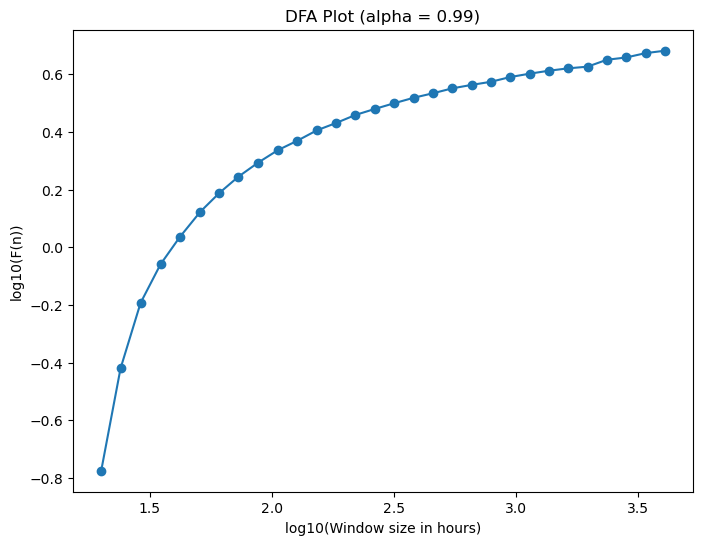

Alpha exponent: 0.986250952206924


In [7]:
from nolds.measures import dfa
import numpy as np
import matplotlib.pyplot as plt

x = df['pm2.5'].values
x = x - np.mean(x)

alpha, debug = dfa(x, debug_data=True)

# raw (actual window sizes in hours)
scales = np.exp(debug[0])
flucts = debug[1]

# PRINT raw values
print("RAW SCALES (hours):")
print(scales)

print("\nRAW FLUCTUATIONS:")
print(flucts)

# PLOT in log-log space (correct DFA form)
plt.figure(figsize=(8,6))
plt.plot(np.log10(scales), np.log10(flucts), 'o-')

plt.xlabel("log10(Window size in hours)")
plt.ylabel("log10(F(n))")
plt.title(f"DFA Plot (alpha = {alpha:.2f})")

plt.show()

print("Alpha exponent:", alpha)


RAW nvals (hours):
[    7     9    10    12    14    16    19    22    26    30    34    40
    46    54    62    72    84    98   113   131   152   176   204   237
   275   318   369   427   495   574   665   771   894  1036  1200  1391
  1612  1868  2165  2509  2907  3369  3904  4524  5243  6075  7040  8158
  9454 10956]

RAW fluctuations:
[1.94591015 2.19722458 2.30258509 2.48490665 2.63905733 2.77258872
 2.94443898 3.09104245 3.25809654 3.40119738 3.52636052 3.68887945
 3.8286414  3.98898405 4.12713439 4.27666612 4.4308168  4.58496748
 4.72738782 4.87519732 5.02388052 5.170484   5.31811999 5.46806014
 5.6167711  5.76205138 5.91079664 6.05678401 6.20455776 6.3526294
 6.49978704 6.64768837 6.79570578 6.94312242 7.09007684 7.23777819
 7.38523092 7.53262362 7.68017564 7.82763955 7.9748769  8.12237124
 8.26975695 8.41715184 8.56464913 8.71193727 8.85936345 9.00675432
 9.15419321 9.30164253]


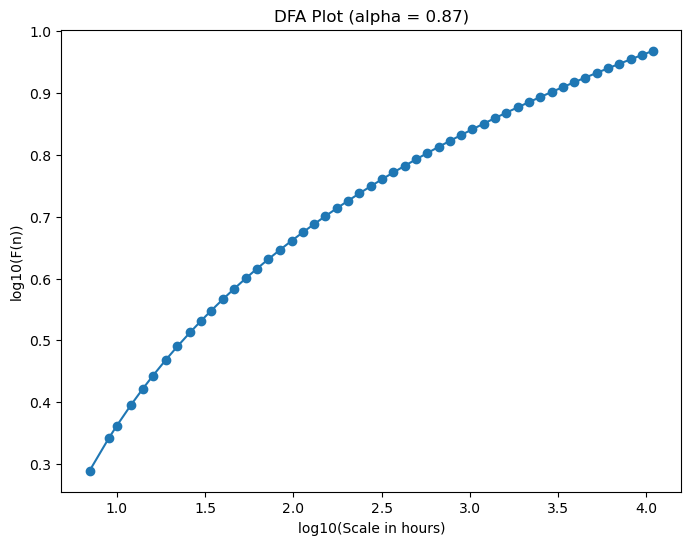


Alpha exponent: 0.8724895898821562


In [8]:
from nolds.measures import dfa
import numpy as np
import matplotlib.pyplot as plt

x = df['pm2.5'].values
x = x - np.mean(x)

# -----------------------------------
# 1. LOG-SPACED 50 SCALE VALUES
# -----------------------------------
start = 8
max_scale = len(x) // 4

nvals = np.unique(
    np.logspace(np.log10(start),
                np.log10(max_scale),
                50).astype(int)
)

# -----------------------------------
# 2. PRINT RAW VALUES (UNLOGGED)
# -----------------------------------
print("RAW nvals (hours):")
print(nvals)

alpha, debug = dfa(x, nvals=nvals, debug_data=True)

scales = nvals
fluctuations = debug[0]

print("\nRAW fluctuations:")
print(fluctuations)

# -----------------------------------
# 3. LOG-LOG PLOT
# -----------------------------------
plt.figure(figsize=(8,6))
plt.plot(np.log10(scales), np.log10(fluctuations), 'o-')

plt.xlabel("log10(Scale in hours)")
plt.ylabel("log10(F(n))")
plt.title(f"DFA Plot (alpha = {alpha:.2f})")

plt.show()

print("\nAlpha exponent:", alpha)

In [21]:
print(min(scales), max(scales))
print(scales[:20])

63 8764
[  63   82  107  139  180  233  302  392  507  657  852 1104 1430 1853
 2401 3111 4030 5221 6764 8764]


In [10]:
# -----------------------------------
# PARAMETER SENSITIVITY
# -----------------------------------

from nolds.measures import dfa

x = df['pm2.5'].values
x = x - np.mean(x)

configs = [
    (16, len(x)//10),
    (32, len(x)//4),
    (64, len(x)//5)
]

for min_s, max_s in configs:

    scales = np.unique(
        np.logspace(
            np.log10(min_s),
            np.log10(max_s),
            20
        ).astype(int)
    )

    alpha = dfa(x, nvals=scales)

    print(f"Min:{min_s} Max:{max_s} Alpha:{alpha}")

Min:16 Max:4382 Alpha:0.8665422234468646
Min:32 Max:10956 Alpha:0.7746871293023601
Min:64 Max:8764 Alpha:0.7268652877322715


In [11]:
# -----------------------------------
# SURROGATE TESTING
# -----------------------------------

from nolds.measures import dfa

x = df['pm2.5'].values
x = x - np.mean(x)

# original
alpha_original = dfa(x)

# shuffled surrogate
x_shuffled = np.random.permutation(x)

alpha_shuffled = dfa(x_shuffled)

print("Original alpha:", alpha_original)
print("Shuffled alpha:", alpha_shuffled)

Original alpha: 0.986250952206924
Shuffled alpha: 0.4911658783121496


MF-DFA completed

q = 0
scales: [  10   14   20   28   40   57   82  117  166  236  335  477  678  964
 1370 1947 2767 3933 5589 7943]
fluctuations: [  0.29285426   0.49375158   0.84071318   1.3108407    2.1072939
   3.3452894    5.35498262   8.15242946  11.44556775  15.76894325
  21.05316987  27.03896951  33.76159502  42.26497309  54.77602195
  66.71574614  88.0793827  111.02850802 152.1151047  190.66834194]

q = 1
scales: [  10   14   20   28   40   57   82  117  166  236  335  477  678  964
 1370 1947 2767 3933 5589 7943]
fluctuations: [  0.44878361   0.72942373   1.18866137   1.78751408   2.78236192
   4.27529443   6.58630293   9.87242789  13.66796397  18.41228361
  24.19270325  31.53994494  38.15048873  48.72305156  62.0103304
  73.99190985  97.61751079 125.30154032 161.97792144 200.7077866 ]

q = 2
scales: [  10   14   20   28   40   57   82  117  166  236  335  477  678  964
 1370 1947 2767 3933 5589 7943]
fluctuations: [  0.64115652   1.01321866   1.57942013   2.3123404    3.51

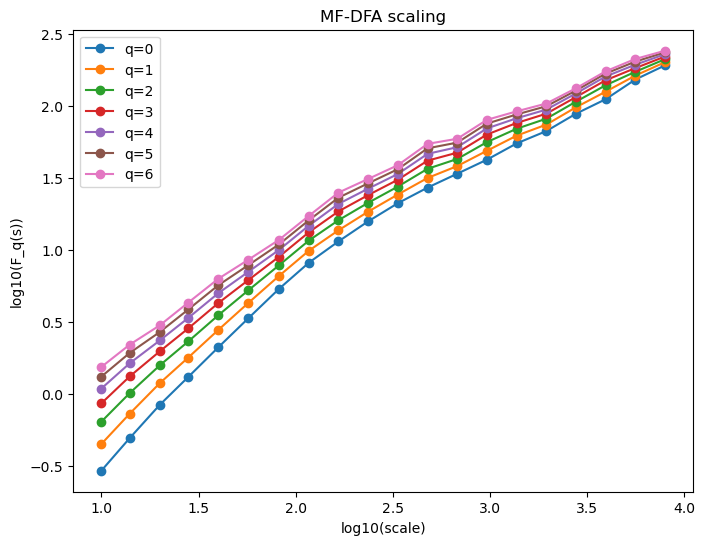

In [31]:
# -----------------------------------
# MF-DFA (FIXED)
# -----------------------------------

from MFDFA import MFDFA
import numpy as np
import matplotlib.pyplot as plt

x = df['pm2.5'].values
x = x - np.mean(x)

# scales
lags = np.unique(
    np.logspace(1, 3.9, 20).astype(int)
)

# q values (keep moderate to avoid instability)
q = np.arange(0, 8)

# avoid zero numerical issues
x = x + 1e-8

lag, fluct = MFDFA(
    x,
    lag=lags,
    q=q
)

print("MF-DFA completed")

for i in range(fluct.shape[1]):
    print(f"\nq = {q[i]}")
    print("scales:", lag)
    print("fluctuations:", fluct[:, i])


eps = 1e-12
x_log = np.log10(lag)

plt.figure(figsize=(8,6))

for i in range(fluct.shape[1]):
    y_log = np.log10(np.clip(fluct[:, i], eps, None))
    plt.plot(x_log, y_log, 'o-', label=f"q={q[i]}")

plt.xlabel("log10(scale)")
plt.ylabel("log10(F_q(s))")
plt.title("MF-DFA scaling")
plt.legend()
plt.show()

In [33]:
from scipy.stats import linregress
import numpy as np

hq = []

eps = 1e-12  # stability threshold

for i in range(fluct.shape[1]):

    y = np.log(np.clip(fluct[:, i], eps, None))
    x = np.log(lag)

    slope, intercept, r, p, se = linregress(x, y)

    hq.append(slope)

hq = np.array(hq)

mf_width = np.max(hq) - np.min(hq)

print("h(q):", hq)
print("Multifractal Width:", mf_width)

h(q): [0.93072802 0.88233584 0.84346837 0.81267528 0.78855754 0.76953466
 0.75427795]
Multifractal Width: 0.1764500730190497


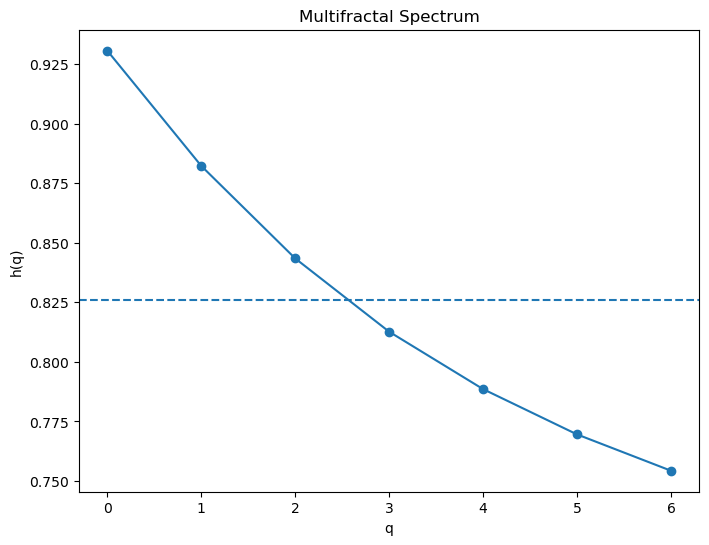

In [34]:
# -----------------------------------
# H(q) CURVE
# -----------------------------------

q_used = q[:len(hq)]

plt.figure(figsize=(8,6))

plt.plot(q_used, hq, marker='o')

plt.xlabel("q")
plt.ylabel("h(q)")
plt.title("Multifractal Spectrum")

plt.axhline(np.mean(hq), linestyle='--')

plt.show()


DFA RESULTS
Original alpha: 0.986250952206924
Surrogate alpha: 0.5044734060794592

MF-DFA RESULTS

Original h(q):
[0.93072802 0.88233584 0.84346837 0.81267528 0.78855754 0.76953466
 0.75427795]

Surrogate h(q):
[0.50671922 0.49891854 0.49144373 0.48416054 0.47698517 0.46991694
 0.46302631]

Original MF width: 0.1764500730190497
Surrogate MF width: 0.04369290450256108


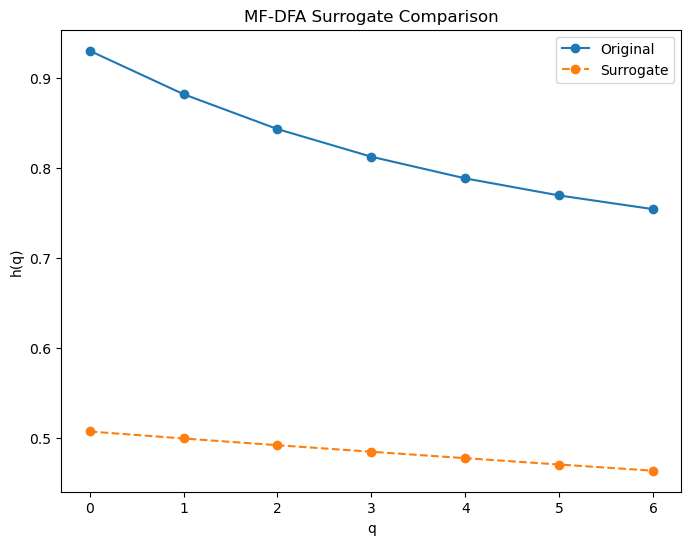

In [35]:
# -----------------------------------
# SURROGATE TESTING FOR DFA + MF-DFA
# -----------------------------------

from nolds.measures import dfa
from MFDFA import MFDFA
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# -----------------------------
# ORIGINAL DATA
# -----------------------------

x = df['pm2.5'].values
x = x - np.mean(x)

# -----------------------------
# SURROGATE (SHUFFLED)
# -----------------------------

x_surrogate = np.random.permutation(x)

# -----------------------------
# DFA COMPARISON
# -----------------------------

alpha_original = dfa(x)
alpha_surrogate = dfa(x_surrogate)

print("DFA RESULTS")
print("Original alpha:", alpha_original)
print("Surrogate alpha:", alpha_surrogate)

# -----------------------------
# MF-DFA SETTINGS
# -----------------------------

lags = np.unique(
    np.logspace(1, 3.9, 20).astype(int)
)

q = np.arange(0, 8)

eps = 1e-12

# -----------------------------
# ORIGINAL MF-DFA
# -----------------------------

lag_o, fluct_o = MFDFA(
    x + 1e-8,
    lag=lags,
    q=q
)

# -----------------------------
# SURROGATE MF-DFA
# -----------------------------

lag_s, fluct_s = MFDFA(
    x_surrogate + 1e-8,
    lag=lags,
    q=q
)

# -----------------------------
# COMPUTE h(q)
# -----------------------------

hq_original = []
hq_surrogate = []

for i in range(fluct_o.shape[1]):

    # original
    y_o = np.log(np.clip(fluct_o[:, i], eps, None))
    x_o = np.log(lag_o)

    slope_o, *_ = linregress(x_o, y_o)
    hq_original.append(slope_o)

    # surrogate
    y_s = np.log(np.clip(fluct_s[:, i], eps, None))
    x_s = np.log(lag_s)

    slope_s, *_ = linregress(x_s, y_s)
    hq_surrogate.append(slope_s)

hq_original = np.array(hq_original)
hq_surrogate = np.array(hq_surrogate)

# -----------------------------
# MULTIFRACTAL WIDTHS
# -----------------------------

width_original = np.max(hq_original) - np.min(hq_original)
width_surrogate = np.max(hq_surrogate) - np.min(hq_surrogate)

print("\nMF-DFA RESULTS")

print("\nOriginal h(q):")
print(hq_original)

print("\nSurrogate h(q):")
print(hq_surrogate)

print("\nOriginal MF width:", width_original)
print("Surrogate MF width:", width_surrogate)

# -----------------------------
# PLOT h(q)
# -----------------------------

q_used = q[:len(hq_original)]

plt.figure(figsize=(8,6))

plt.plot(q_used, hq_original, 'o-', label='Original')
plt.plot(q_used, hq_surrogate, 'o--', label='Surrogate')

plt.xlabel("q")
plt.ylabel("h(q)")
plt.title("MF-DFA Surrogate Comparison")

plt.legend()

plt.show()

In [25]:
# -----------------------------------
# CONDITION-BASED DFA COMPARISON
# -----------------------------------
from nolds.measures import dfa
import pandas as pd
import numpy as np


df['datetime'] = pd.to_datetime(
    df[['year', 'month', 'day', 'hour']]
)

# -----------------------------------
# CREATE CONDITIONS
# -----------------------------------
# weekdays vs weekends

df['is_weekend'] = df['datetime'].dt.weekday >= 5

# -----------------------------------
# CREATE CONDITIONS
# -----------------------------------

# weekdays vs weekends
df['is_weekend'] = df['datetime'].dt.weekday >= 5

# seasons
def get_season(month):

    if month in [12, 1, 2]:
        return 'winter'

    elif month in [3, 4, 5]:
        return 'spring'

    elif month in [6, 7, 8]:
        return 'summer'

    else:
        return 'autumn'

df['season'] = df['datetime'].dt.month.apply(get_season)

# pollution episodes
threshold = df['pm2.5'].quantile(0.90)

df['high_pollution'] = df['pm2.5'] > threshold

# -----------------------------------
# FUNCTION TO COMPUTE DFA
# -----------------------------------

def compute_alpha(series):

    x = series.values

    x = x[~np.isnan(x)]

    if len(x) < 100:
        return np.nan

    x = x - np.mean(x)

    return dfa(x)

# -----------------------------------
# WEEKDAY vs WEEKEND
# -----------------------------------

weekday_alpha = compute_alpha(
    df[df['is_weekend'] == False]['pm2.5']
)

weekend_alpha = compute_alpha(
    df[df['is_weekend'] == True]['pm2.5']
)

print("\nWEEKDAY/WEEKEND")

print("Weekday alpha:", weekday_alpha)
print("Weekend alpha:", weekend_alpha)

# -----------------------------------
# SEASONS
# -----------------------------------

print("\nSEASONAL DFA")

for season in ['winter', 'spring', 'summer', 'autumn']:

    alpha = compute_alpha(
        df[df['season'] == season]['pm2.5']
    )

    print(f"{season}: {alpha}")

# -----------------------------------
# HIGH vs NORMAL POLLUTION
# -----------------------------------

high_alpha = compute_alpha(
    df[df['high_pollution'] == True]['pm2.5']
)

normal_alpha = compute_alpha(
    df[df['high_pollution'] == False]['pm2.5']
)

print("\nPOLLUTION REGIMES")

print("High pollution alpha:", high_alpha)
print("Normal pollution alpha:", normal_alpha)


WEEKDAY/WEEKEND
Weekday alpha: 0.9876303852363214
Weekend alpha: 1.008502320237431

SEASONAL DFA
winter: 1.1179313857944888
spring: 1.0870815480785156
summer: 1.0893464623631084
autumn: 1.1378209203477674

POLLUTION REGIMES
High pollution alpha: 0.9997591896707518
Normal pollution alpha: 0.9113990828677652


month        1         2         3         4         5         6         7   \
year                                                                          
2010        NaN  1.156395  1.141016  1.195085  1.229142  1.205693  1.225975   
2011   1.284641  1.304113  1.315086  1.308742  1.245099  1.280301  1.278246   
2012   1.207465  1.244262  1.280986  1.293097  1.217060  1.224344  1.271447   
2013   1.308983  1.301382  1.297967  1.293812  1.241120  1.198087  1.188565   
2014   1.309383  1.335764  1.352673  1.272174  1.198854  1.228002  1.254283   

month        8         9         10        11        12  
year                                                     
2010   1.246072  1.329632  1.324470  1.336611  1.306881  
2011   1.312375  1.328456  1.310382  1.268175  1.217258  
2012   1.337325  1.338427  1.323865  1.325292  1.309414  
2013   1.234828  1.338348  1.339967  1.316761  1.276617  
2014   1.267953  1.391236  1.399515  1.409448       NaN  


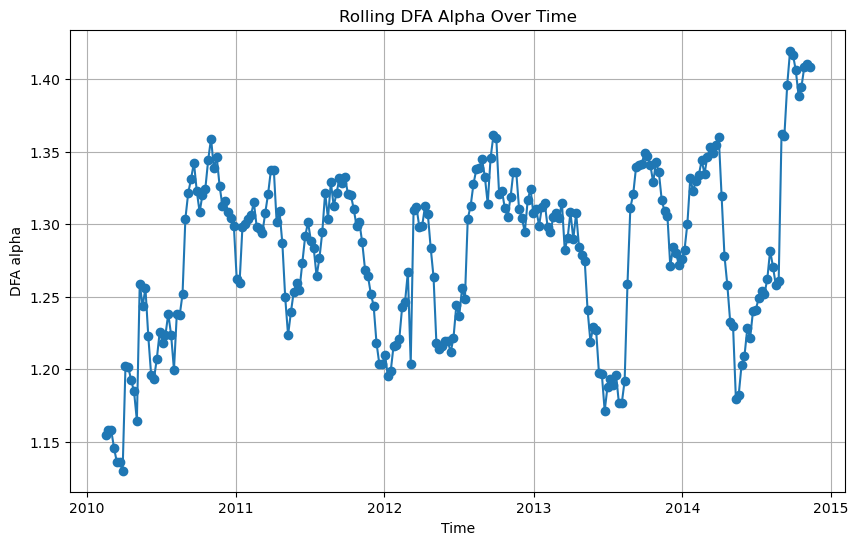

In [ ]:
# -----------------------------------
# ROLLING DFA OVER TIME
# -----------------------------------

from nolds.measures import dfa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------
# BUILD DATETIME
# -----------------------------------

df['datetime'] = pd.to_datetime(
    df[['year', 'month', 'day', 'hour']]
)

# -----------------------------------
# SETTINGS
# -----------------------------------

window_size = 2184   # seasons
step_size = 168      # week

# -----------------------------------
# STORAGE
# -----------------------------------

times = []
alphas = []

x_all = df['pm2.5'].values

# -----------------------------------
# ROLLING WINDOWS
# -----------------------------------

for start in range(0, len(x_all) - window_size, step_size):
    end = start + window_size
    x = x_all[start:end]
    # remove NaNs
    x = x[~np.isnan(x)]
    # mean center
    x = x - np.mean(x)
    # compute DFA alpha
    alpha = dfa(x)
    # save
    alphas.append(alpha)
    # midpoint time
    mid_idx = start + window_size // 2
    times.append(df['datetime'].iloc[mid_idx])

# -----------------------------------
# PRINT RESULTS
# -----------------------------------


results_df = pd.DataFrame({
    'datetime': times,
    'alpha': alphas

})

# extract year + month
results_df['year'] = results_df['datetime'].dt.year
results_df['month'] = results_df['datetime'].dt.month

# -----------------------------------
# PIVOT TABLE
# -----------------------------------

pivot_table = results_df.pivot_table(
    values='alpha',
    index='year',
    columns='month',
    aggfunc='mean'

)

# optional: sort months
pivot_table = pivot_table.sort_index(axis=1)

print(pivot_table)

# -----------------------------------
# PLOT
# -----------------------------------

plt.figure(figsize=(10,6))

plt.plot(times, alphas, 'o-')

plt.xlabel("Time")
plt.ylabel("DFA alpha")
plt.title("Rolling DFA Alpha Over Time")

plt.grid(True)

plt.show()

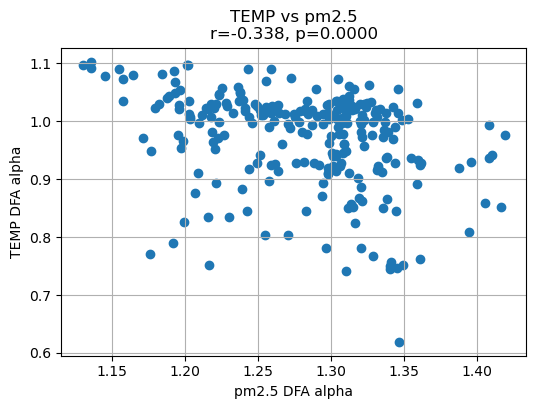

TEMP: r=-0.3382, p=0.0000, windows=248


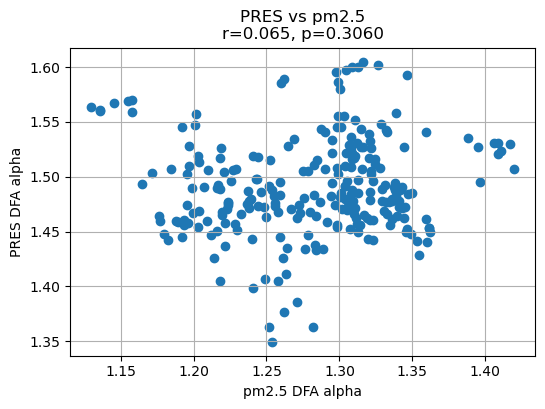

PRES: r=0.0653, p=0.3060, windows=248


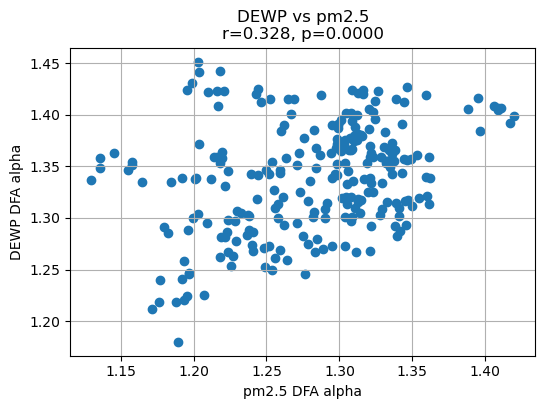

DEWP: r=0.3285, p=0.0000, windows=248


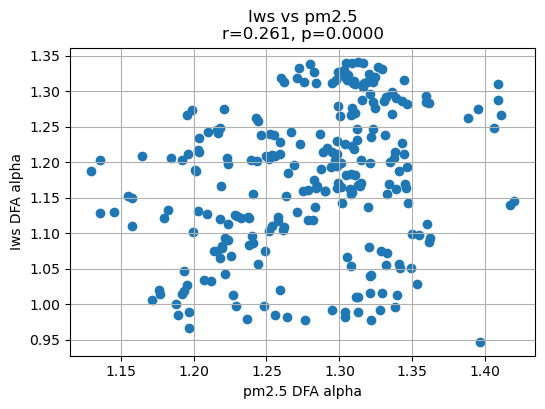

Iws: r=0.2613, p=0.0000, windows=248


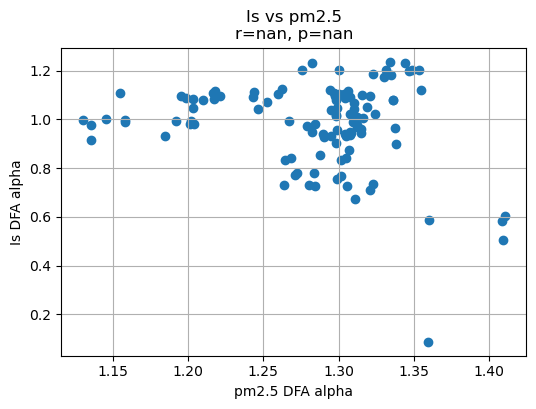

Is: r=nan, p=nan, windows=248


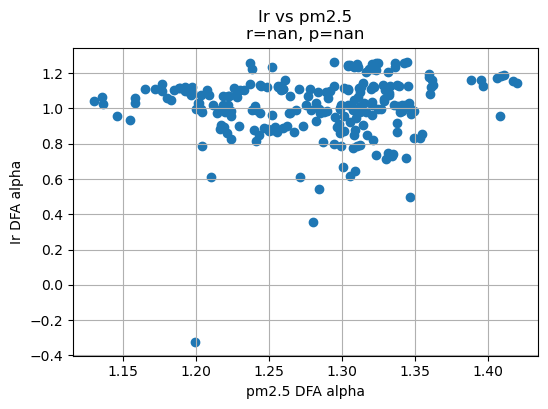

Ir: r=nan, p=nan, windows=248

FINAL RESULTS:
  variable         r             p  n_windows
2     DEWP  0.328468  1.195334e-07        248
3      Iws  0.261306  3.087777e-05        248
1     PRES  0.065264  3.059907e-01        248
0     TEMP -0.338176  4.750302e-08        248
4       Is       NaN           NaN        248
5       Ir       NaN           NaN        248


In [36]:
# -----------------------------------
# COMPLEXITY MATCHING (PM2.5 vs ALL VARIABLES)
# WITH PLOTS + RESULTS
# -----------------------------------

from nolds.measures import dfa
from scipy.stats import pearsonr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------
# SETTINGS
# -----------------------------------

window_size = 2184
step_size = 168

target = 'pm2.5'

vars_list = ['TEMP', 'PRES', 'DEWP', 'Iws', 'Is', 'Ir']

# -----------------------------------
# STORAGE
# -----------------------------------

results = []

# -----------------------------------
# LOOP THROUGH VARIABLES
# -----------------------------------

for var2 in vars_list:

    alpha_target = []
    alpha_var = []

    for start in range(0, len(df) - window_size, step_size):

        end = start + window_size

        x1 = df[target].iloc[start:end].values
        x2 = df[var2].iloc[start:end].values

        # remove NaNs jointly
        mask = ~np.isnan(x1) & ~np.isnan(x2)
        x1 = x1[mask]
        x2 = x2[mask]

        if len(x1) < 100:
            continue

        # mean center
        x1 = x1 - np.mean(x1)
        x2 = x2 - np.mean(x2)

        # DFA
        a1 = dfa(x1)
        a2 = dfa(x2)

        alpha_target.append(a1)
        alpha_var.append(a2)

    # skip weak cases
    if len(alpha_target) < 5:
        continue

    # correlation
    r, p = pearsonr(alpha_target, alpha_var)

    results.append((var2, r, p, len(alpha_target)))

    # -----------------------------------
    # PLOT FOR EACH VARIABLE
    # -----------------------------------

    plt.figure(figsize=(6,4))

    plt.scatter(alpha_target, alpha_var)

    plt.xlabel("pm2.5 DFA alpha")
    plt.ylabel(f"{var2} DFA alpha")

    plt.title(f"{var2} vs pm2.5\nr={r:.3f}, p={p:.4f}")

    plt.grid(True)

    plt.show()

    # print per-variable summary
    print(f"{var2}: r={r:.4f}, p={p:.4f}, windows={len(alpha_target)}")

# -----------------------------------
# RESULTS DATAFRAME
# -----------------------------------

results_df = pd.DataFrame(
    results,
    columns=["variable", "r", "p", "n_windows"]
)

print("\nFINAL RESULTS:")
print(results_df.sort_values(by="r", ascending=False))